In [1]:
#makemore part4! 继续学习！

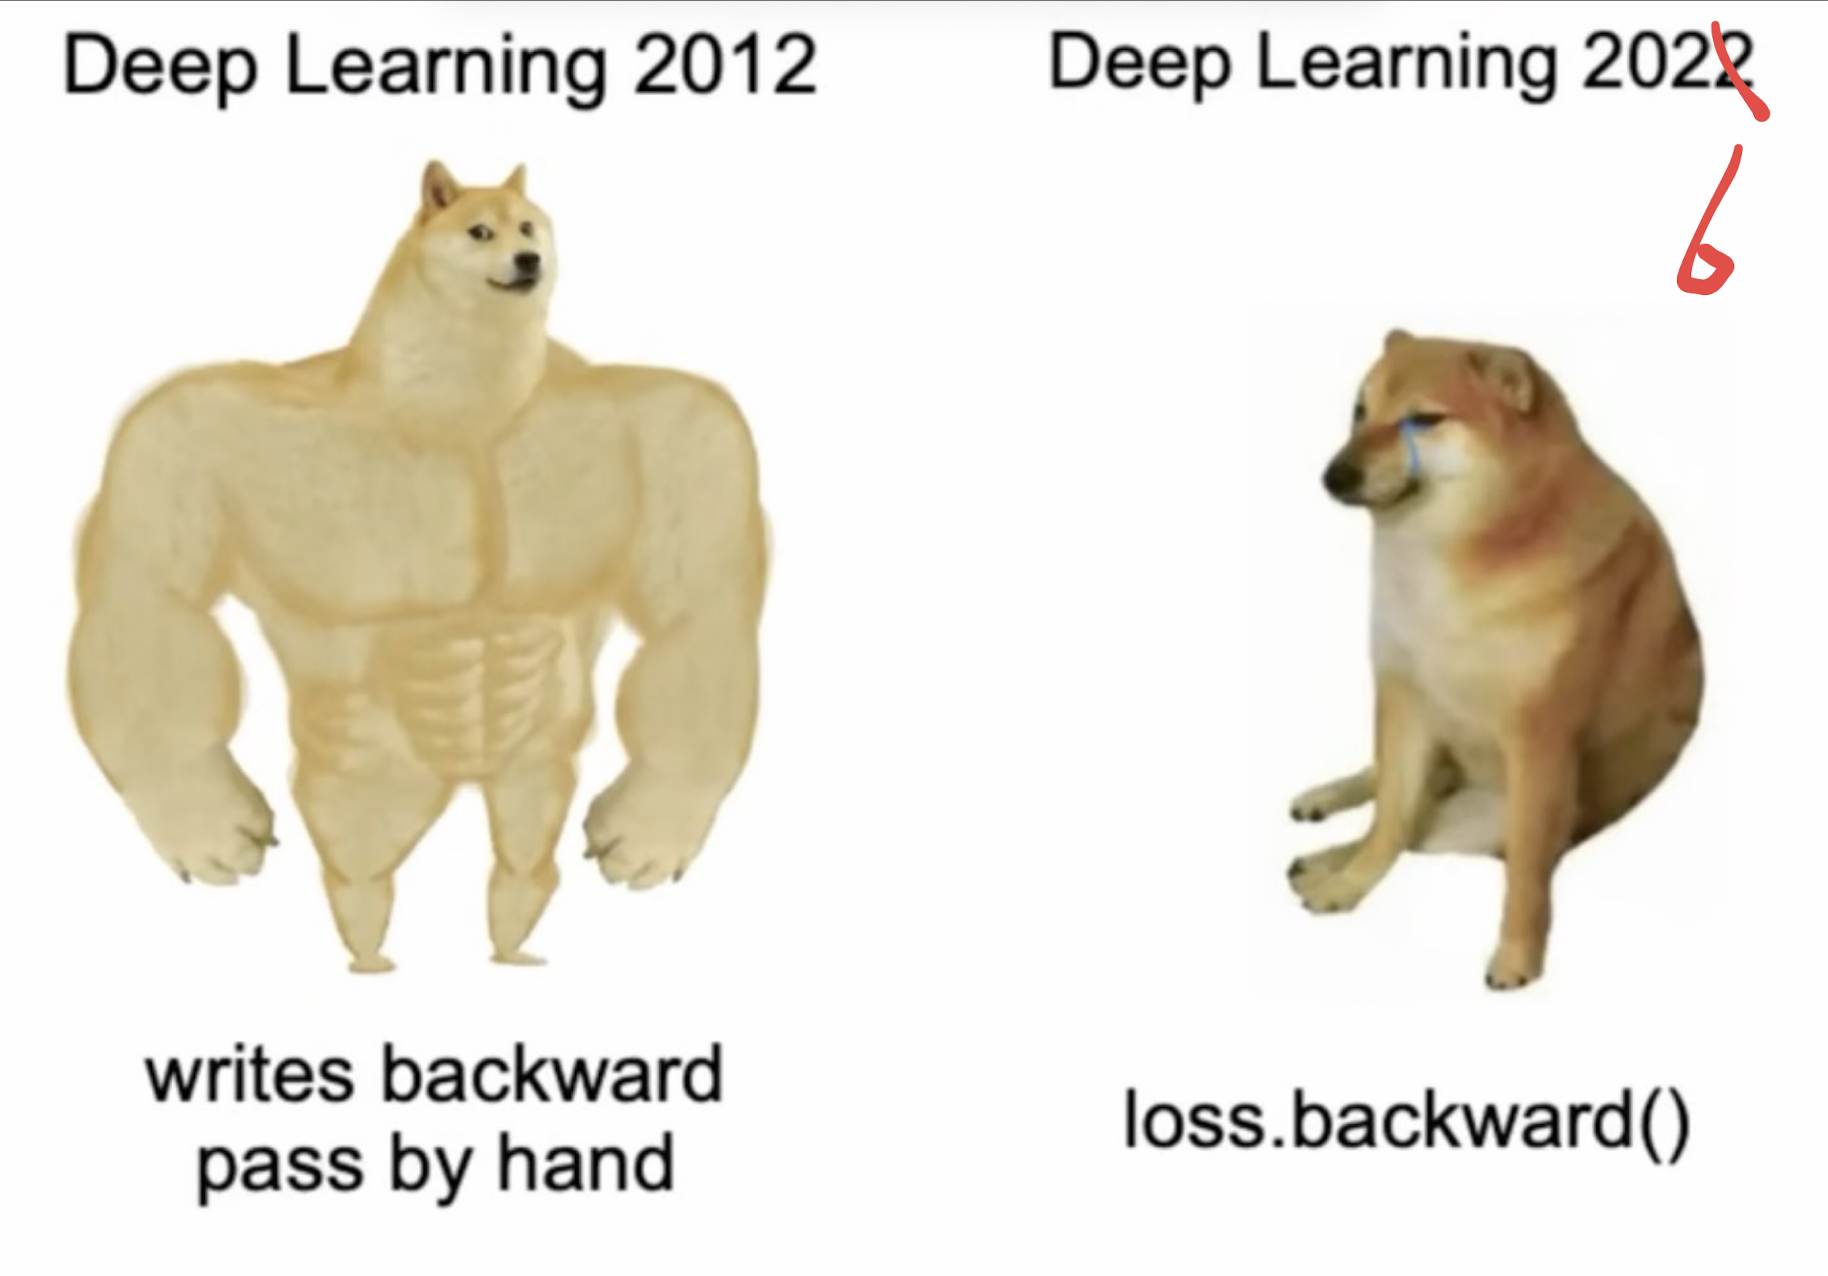

In [2]:
#这一章主要是手写pytorch的反向传播
#之前的反向传播太简单了
#loss.backward()就结束了
#但事实上这是极容易出错的
#所以我们需要重新来实现一下

In [3]:
#前面的初始化代码是一样的

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
words=open("names.txt","r").read().splitlines()
words[:3]

['emma', 'olivia', 'ava']

In [6]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)
vocab_size=len(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
block_size=3

def build_dataset(words,block_size):
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)#打印数据集的大小
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)#0%~80%
Xdev, Ydev = build_dataset(words[n1:n2],block_size)#80%~90%
Xte, Yte = build_dataset(words[n2:],block_size)#90~100%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
#这是一个辅助比较工具函数
#因为我们需要实现手写的反向传播
#这个函数可以让我们写出来的结果和pytorch的结果相比较
#还能判断误差是多少
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()#比较我们计算的grad和torch生成的grad
  app = torch.allclose(dt, t.grad)#排除浮点数精度问题
  maxdiff = (dt - t.grad).abs().max().item()#看看最大的差值
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [9]:
#一样的初始化，只不过微调了下数值
g = torch.Generator().manual_seed(2147483647)

n_embd=10
n_hidden=200

C = torch.randn((vocab_size, n_embd),          generator=g)         
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*(5/3)/((block_size*n_embd)**0.5)
b1 = torch.randn(n_hidden,                     generator=g)*0.1  
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.1  
b2 = torch.randn(vocab_size,                   generator=g)*0.1      

bngain=torch.ones((1,n_hidden))*0.1+1.0
bnbias=torch.zeros((1,n_hidden))*0.1

parameters = [C, W1, b1, W2, b2]
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

总参数量：11897


In [10]:
#接下来是前向传播的训练部分
#这里andrej把我们之前写的一些东西给拆分成了不同的模块
#因为这里我们要实现backward的手动推导
#所以需要我们小心地去处理计算的部分
#所以这里把一些步骤拆分了出来
batch_size=32
n=batch_size

ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
Xb,Yb=Xtr[ix],Ytr[ix]

emb = C[Xb]
embcat=emb.view(batch_size, block_size*n_embd)
hprebn=embcat@ W1 + b1#h pre bn 在batchnorm之前的h

#bnmeani
bnmeani=hprebn.sum(0,keepdim=True)*(1/n)#这里就是求mean

#hprebn - bnmeani
bndiff=hprebn-bnmeani

#1/bnstdi
bndiff2=bndiff**2
bnvar=1/(n-1)*(bndiff2).sum(0,keepdim=True)
bnvar_inv=(bnvar+1e-5)**-0.5

#(hprebn - bnmeani) / bnstdi
bnraw=bndiff*bnvar_inv

#hpreact
hpreact=bngain*bnraw+bnbias

#h
h=torch.tanh(hpreact)

#logits
logits=h@W2+b2 

#以下是cross_entropy的手动实现
#对logits进行处理，避免出现过大值导致后面的exp出现NaN
logit_maxes=logits.max(1,keepdim=True).values
norm_logits=logits-logit_maxes

#softmax
counts=norm_logits.exp()
counts_sum=counts.sum(1,keepdim=True)
counts_sum_inv=counts_sum**-1
probs=counts*counts_sum_inv

#最大负对数似然
logprobs=probs.log()
loss=-logprobs[range(n),Yb].mean()

#清空梯度
for p in parameters:
    p.grad=None

#保留梯度，可以查看每一步反向传播的具体数值
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
          bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
          embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.8279, grad_fn=<NegBackward0>)

In [11]:
#接下来的部分我们就是手动实现上面的那一长串的运算过程
#而且反向传播是反过来一级一级去算
#所以我们应当反过来，从后往前一步步求grad

In [12]:
#第一个是logprobs
#求grad就是反过来去看运算过程

In [13]:
logprobs.shape,logprobs[range(n),Yb].shape

(torch.Size([32, 27]), torch.Size([32]))

In [14]:
#可以看到logprobs的shape是batch_size*vocab_size
#下一步是求了每一行的所对应的Yb的对应元素，然后取平均
#也就是说：这一步最后就是32个元素取平均
#那对于这一步，也就是-(++++)/32
#那对于这32个的每一个，grad都是-1/batch_size
#然后对于除了这32个以外的其他元素，grad显然都是0

In [15]:
dlogprobs=torch.zeros_like(logprobs)#这里意思是生成和logprobs形状一样的0张量
dlogprobs[range(n),Yb]=-1.0/n

In [16]:
cmp("logprobs",dlogprobs,logprobs)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0


In [17]:
#结果正确，logprobs的反向传播函数正确

In [18]:
#probs
#probs->logprobs就是一步log，很简单

In [19]:
dprobs=(1/probs)*dlogprobs
#这里已经不是单层了，所以要乘上下一层的d

In [20]:
cmp("probs",dprobs,probs)

probs           | exact: True  | approximate: True  | maxdiff: 0.0


In [21]:
#probs正确

In [22]:
#counts_sum_inv

In [23]:
#这个是logits到probs的归一化过程
#logits先进行大值处理
#然后exp后归一化
#这个counts_sum_inv其实就是归一化后的分母

In [24]:
counts_sum_inv.shape,counts.shape

(torch.Size([32, 1]), torch.Size([32, 27]))

In [25]:
#所以每一个counts_sum_inv其实都是counts的一行的exp求和

In [26]:
#所以不难发现counts_sum_inv到probs的计算就是：
#a*C=A,b*C=B,c*C=c,......
#那这样的话每一个C的grad其实就是所有求一遍的和
#但是每一个需要和probs的grad乘一下

In [27]:
dcounts_sum_inv=(counts*dprobs).sum(1,keepdim=True)

In [28]:
cmp("counts_sum_inv",dcounts_sum_inv,counts_sum_inv)

counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0


In [29]:
#counts_sum_inv正确

In [30]:
#counts_sum

In [35]:
#这个很简单，就是单纯的-1次方
dcounts_sum=(-1*counts_sum**-2)*dcounts_sum_inv

In [36]:
cmp("counts_sum",dcounts_sum,counts_sum)

counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0


In [37]:
#counts

In [38]:
#counts在计算中有两条路径
#一个是->counts_sum->counts_sum_inv
#另一个是直接作用到了probs上

In [ ]:
counts_sum.shape,